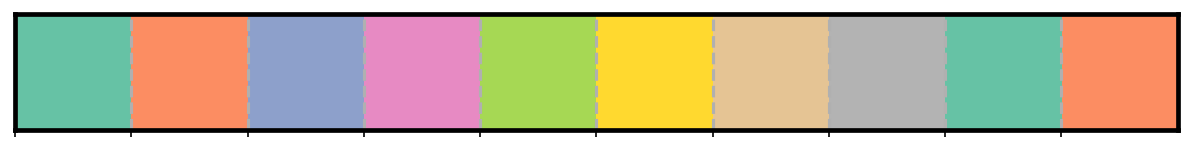

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib
from sklearn.metrics import roc_curve


def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [ ]:
train_test_data = pd.read_csv("earning_potential_train_test_AMAS_2026.txt", delimiter=",")

In [ ]:
train_test_data

,ID,age,education,gender,hours-per-week,earning
0,0,39,13,0,40,<=50K
1,1,50,13,0,13,<=50K
2,2,38,9,0,40,<=50K
3,3,53,7,0,40,<=50K
4,4,28,13,1,40,<=50K
...,...,...,...,...,...,...
4795,4795,34,13,0,40,<=50K
4796,4796,29,11,1,40,<=50K
4797,4797,46,13,0,50,>50K
4798,4798,36,9,0,40,<=50K


In [ ]:
train_test_data['earning']

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
4795     <=50K
4796     <=50K
4797      >50K
4798     <=50K
4799     <=50K
Name: earning, Length: 4800, dtype: str

In [ ]:
print("Data type:", train_test_data['earning'].dtype)
print("Unique values:", train_test_data['earning'].unique())
print("Value counts:\n", train_test_data['earning'].value_counts())


Data type: str
Unique values: <StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str
Value counts:
 earning
<=50K    3639
>50K     1161
Name: count, dtype: int64


In [ ]:
# fig, ax = plt.subplots(2, 2, figsize=(16, 10))
# ax = ax.flatten()

# features = ['age', 'education', 'gender', 'hours-per-week']
# titles = ['Age', 'Education', 'Gender', 'Hours per Week']

# for idx, (feature, title) in enumerate(zip(features, titles)):
#     ax[idx].hist(train_high[feature], bins=30, label='High Earners (>50K)', color='green', alpha=0.6)
#     ax[idx].hist(train_low[feature], bins=30, label='Low Earners (<=50K)', color='red', alpha=0.6)
    
#     ax[idx].set_xlabel(title)
#     ax[idx].set_ylabel('Count')
#     ax[idx].set_title(f'{title} Distribution by Earnings')
#     ax[idx].legend()

# plt.tight_layout()
# plt.show()


In [ ]:
# fig, ax = plt.subplots(2, 3, figsize=(18, 10))
# ax = ax.flatten()

# features = ['age', 'education', 'gender', 'hours-per-week']

# # Create all combinations of features
# plot_idx = 0
# for i in range(len(features)):
#     for j in range(i + 1, len(features)):
#         if plot_idx < 6:  # Only 6 subplots (2x3)
#             feature1 = features[i]
#             feature2 = features[j]
            
#             # Scatter plot for high earners
#             ax[plot_idx].scatter(train_high[feature1], train_high[feature2], 
#                                 alpha=0.6, label='High Earners (>50K)', s=30)
            
#             # Scatter plot for low earners
#             ax[plot_idx].scatter(train_low[feature1], train_low[feature2], 
#                                 alpha=0.6, label='Low Earners (<=50K)', s=30)
            
#             ax[plot_idx].set_xlabel(feature1.capitalize())
#             ax[plot_idx].set_ylabel(feature2.capitalize())
#             ax[plot_idx].set_title(f'{feature2.capitalize()} vs {feature1.capitalize()}')
#             ax[plot_idx].legend()
            
#             plot_idx += 1

# plt.tight_layout()
# plt.show()

In [ ]:
# min test
min_test_samples = 500

#binary
train_test_data['earning'] = (train_test_data['earning'] == ' >50K').astype(int)

#filter
high_earners = train_test_data[train_test_data['earning'] == 1]
low_earners = train_test_data[train_test_data['earning'] == 0]

Nhigh_train = len(high_earners) - min_test_samples
Nlow_train = int(len(low_earners)/len(high_earners) * Nhigh_train) # Scale low earners to maintain class balance in training set


frac_low_train = Nlow_train / (Nlow_train+Nhigh_train)
frac_high_train = Nhigh_train / (Nlow_train+Nhigh_train)
print(f"Fraction of high earners in training set: {frac_high_train:.2f}")
print(f"Fraction of low earners in training set: {frac_low_train:.2f}")
#sampling
train_high = high_earners.sample(Nhigh_train, random_state=42)
train_low = low_earners.sample(Nlow_train, random_state=42)

test_high = high_earners.drop(train_high.index)
test_low = low_earners.drop(train_low.index)

X_train = pd.concat([train_high, train_low])[['age', 'education', 'gender', 'hours-per-week']].values
y_train = pd.concat([train_high, train_low])['earning'].values

X_test = pd.concat([test_high, test_low])[['age', 'education', 'gender', 'hours-per-week']].values
y_test = pd.concat([test_high, test_low])['earning'].values

print(f"Train - High: {len(train_high)}, Low: {len(train_low)}")
print(f"Test - High: {len(test_high)}, Low: {len(test_low)}")
print(f"Total Train: {len(X_train)}, Total Test: {len(X_test)}")

Fraction of high earners in training set: 0.24
Fraction of low earners in training set: 0.76
Train - High: 661, Low: 2071
Test - High: 500, Low: 1568
Total Train: 2732, Total Test: 2068


In [ ]:

# Create and train the model
model = XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)


auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Manual accuracy: {accuracy:.4f}")



AUC: 0.8171
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1568
           1       0.57      0.45      0.50       500

    accuracy                           0.78      2068
   macro avg       0.70      0.67      0.68      2068
weighted avg       0.77      0.78      0.77      2068

Manual accuracy: 0.7834


In [ ]:
#random_search
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}


random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    n_iter=400,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [ ]:

y_pred_proba = best_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(best_thresh)




####Uncomment here to set threshold or not:

#y_pred = best_model.predict(X_test)
y_pred = (y_pred_proba[:,1] >= best_thresh).astype(int)



auc = roc_auc_score(y_test, y_pred_proba[:, 1])
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest AUC: {auc:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))


0.23417428135871887

Test AUC: 0.8374
Test Accuracy: 0.7108
              precision    recall  f1-score   support

           0       0.94      0.66      0.78      1568
           1       0.45      0.86      0.59       500

    accuracy                           0.71      2068
   macro avg       0.69      0.76      0.68      2068
weighted avg       0.82      0.71      0.73      2068



In [ ]:
train_pred = best_model.predict(X_train)
train_proba = best_model.predict_proba(X_train)

train_auc = roc_auc_score(y_train, train_proba[:, 1])
train_accuracy = accuracy_score(y_train, train_pred)

test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Big difference = overfitting
if train_accuracy - test_accuracy > 0.1:
    print("Possible overfitting!")

Train AUC: 0.8535, Test AUC: 0.8374
Train Accuracy: 0.8100, Test Accuracy: 0.7108


In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(best_thresh)


0.23417428135871887


In [ ]:
#init
y_pred_manual = model.predict(X_test)
manual_acc = accuracy_score(y_test, y_pred_manual)
print(f"Manual model accuracy: {manual_acc:.4f}")

# optimized w default threshold
y_pred_default = best_model.predict(X_test)
default_acc = accuracy_score(y_test, y_pred_default)
print(f"Best model (0.5 threshold) accuracy: {default_acc:.4f}")

#optimized w optimal threshold
y_pred_optimal = (y_pred_proba[:, 1] >= best_thresh).astype(int)
optimal_acc = accuracy_score(y_test, y_pred_optimal)
print(f"Best model (optimal threshold) accuracy: {optimal_acc:.4f}")
print(f"Optimal threshold: {best_thresh:.4f}")

#train accuracy
train_proba = best_model.predict_proba(X_train)
train_pred_optimal = (train_proba[:, 1] >= best_thresh).astype(int)
train_accuracy = accuracy_score(y_train, train_pred_optimal)
print(f"Train accuracy with optimal threshold: {train_accuracy:.4f}")

Manual model accuracy: 0.7834
Best model (0.5 threshold) accuracy: 0.8003
Best model (optimal threshold) accuracy: 0.7108
Optimal threshold: 0.2342
Train accuracy with optimal threshold: 0.7339


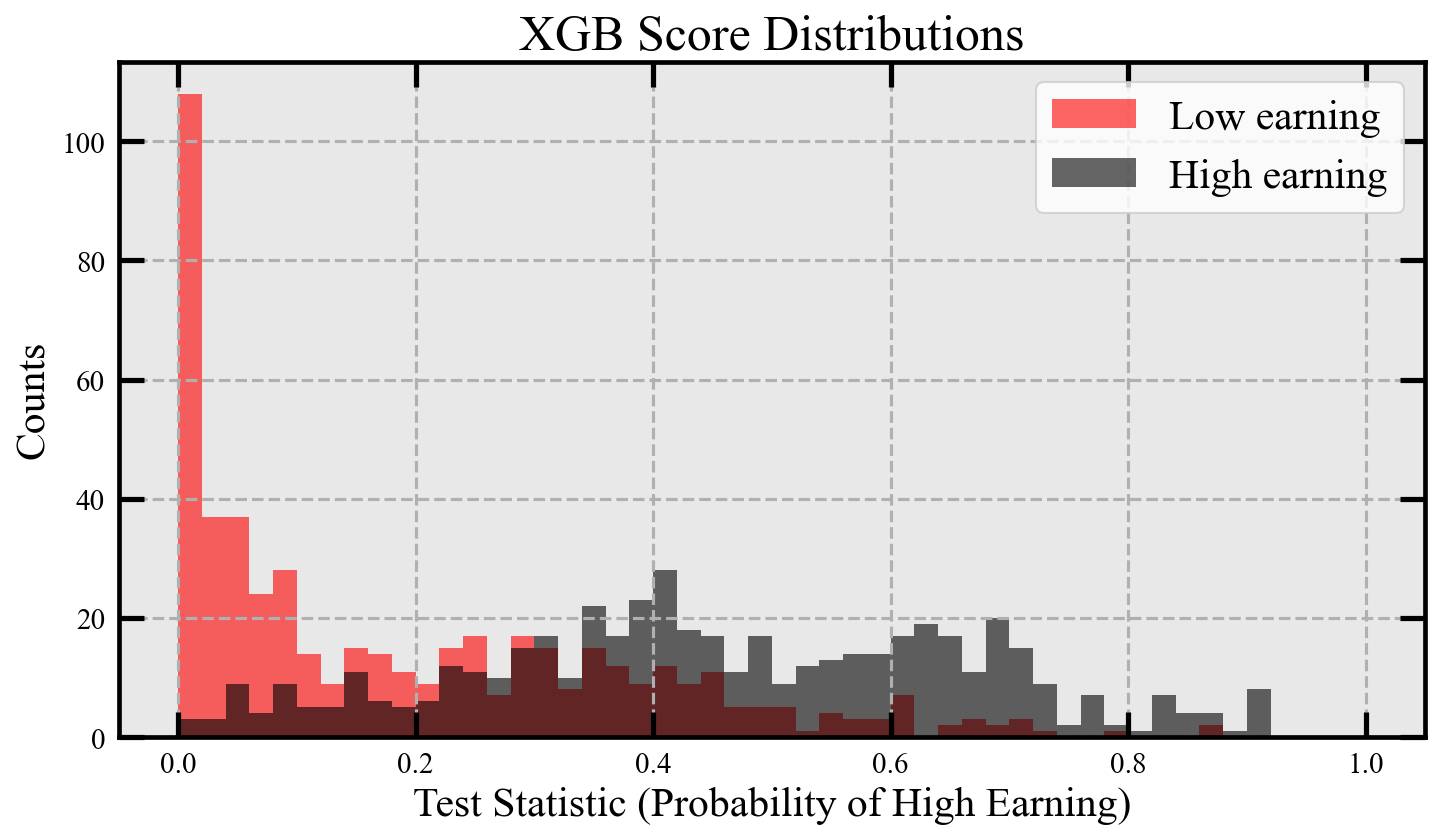

In [ ]:

test_statistic = y_pred_proba[:, 1]  

#seperate
low_scores = test_statistic[len(test_high):]  # Low earners (class 0)
high_scores = test_statistic[:len(test_high)]  # High earners (class 1)

low_plot = low_scores[:500]
high_plot = high_scores[:500]

Nbins = 50
xrange = (0,1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(low_plot, bins=Nbins, range=xrange, alpha=0.6, color = 'red', label='Low earning', density=False)
ax.hist(high_plot, bins=Nbins, range=xrange, alpha=0.6, color = 'black', label='High earning', density=False)
ax.set_xlabel('Test Statistic (Probability of High Earning)')
ax.set_ylabel('Counts')
ax.set_title('XGB Score Distributions')
ax.legend()
stylize_ticks(fig, ax)
plt.tight_layout()
plt.show()

In [ ]:
validation_data = pd.read_csv('earning_potential_real_2026.txt')

In [ ]:
X_val=validation_data[['age', 'education', 'gender', 'hours-per-week']].values


In [ ]:
y_pred = best_model.predict(X_val)
y_pred_proba = best_model.predict_proba(X_val)

In [ ]:
print(y_pred)
print(y_pred_proba)

[0 0 0 ... 0 0 1]
[[0.8984553  0.10154466]
 [0.98097473 0.01902529]
 [0.71575093 0.28424904]
 ...
 [0.95874333 0.0412567 ]
 [0.94537854 0.05462144]
 [0.34092468 0.6590753 ]]


In [ ]:
y_pred_proba = best_model.predict_proba(X_val)
#y_pred = best_model.predict(X_val)
y_pred = (y_pred_proba[:,1] >= best_thresh).astype(int)
test_statistic = y_pred_proba[:, 1]  # Probability of being high earner (>50K)

#ID
ids = validation_data['ID'].values

#preds
predicted_low = test_statistic[y_pred == 0]
predicted_high = test_statistic[y_pred == 1]

low_indices = np.where(y_pred == 0)[0]
high_indices = np.where(y_pred == 1)[0]

low_ids = ids[low_indices]
high_ids = ids[high_indices]

#files
with open('low_earners.txt', 'w') as f:
    for id_val in low_ids:
        f.write(f"{id_val}\n")

with open('high_earners.txt', 'w') as f:
    for id_val in high_ids:
        f.write(f"{id_val}\n")

print(f"Wrote {len(low_ids)} low earner IDs to low_earners.txt")
print(f"Wrote {len(high_ids)} high earner IDs to high_earners.txt")



Wrote 3439 low earner IDs to low_earners.txt
Wrote 3073 high earner IDs to high_earners.txt


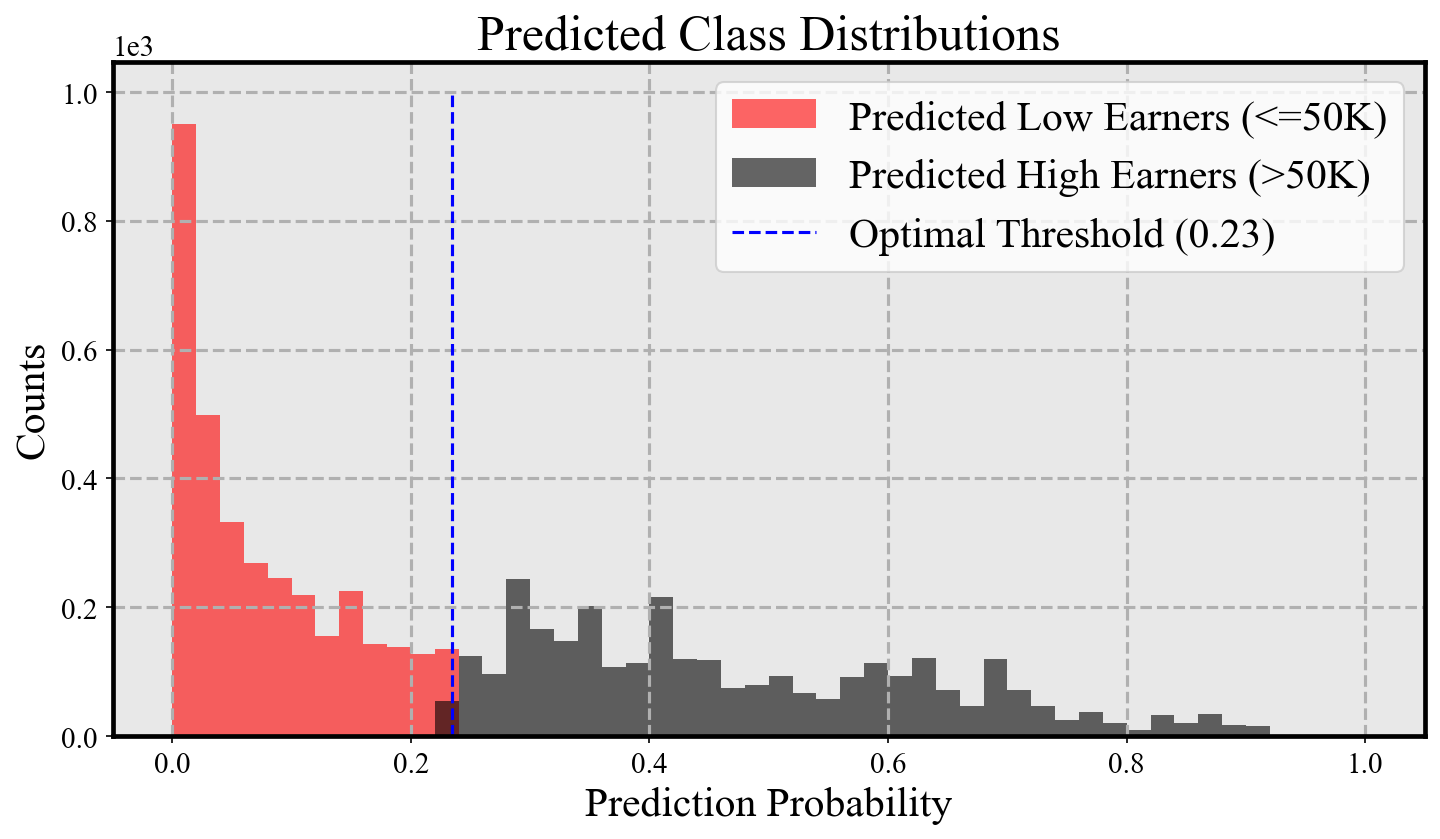

Predicted Low Earners: 3439
Predicted High Earners: 3073


In [ ]:
Nbins = 50
xrange = (0, 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predicted_low, bins=Nbins, range=xrange, alpha=0.6, color='red', label='Predicted Low Earners (<=50K)', density=False)
ax.hist(predicted_high, bins=Nbins, range=xrange, alpha=0.6, color='black', label='Predicted High Earners (>50K)', density=False)
ax.vlines(best_thresh, ymin=0, ymax=max(ax.get_ylim()), colors='blue', linestyles='dashed', label=f'Optimal Threshold ({best_thresh:.2f})')
ax.set_xlabel('Prediction Probability')
ax.set_ylabel('Counts')
ax.set_title('Predicted Class Distributions')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Predicted Low Earners: {len(predicted_low)}")
print(f"Predicted High Earners: {len(predicted_high)}")
